In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [38]:
# Organize the excel file in a dataframe
df = pd.read_excel("Concrete_Data.xls")

# Seperate the target variable (Concrete compressive strength) from the rest "predicting" attributes
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '], axis=1)
# Target variable
y= df['Concrete compressive strength(MPa, megapascals) '].values

# Split data in training and test tests
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
# Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

Fold 1: λ*=1.5923, h*=20, Ridge MSE=122.497, ANN MSE=51.213, Baseline MSE=333.285
Fold 2: λ*=1.0975, h*=20, Ridge MSE=94.281, ANN MSE=67.745, Baseline MSE=236.903
Fold 3: λ*=1.5923, h*=20, Ridge MSE=144.101, ANN MSE=76.049, Baseline MSE=343.287
Fold 4: λ*=0.9112, h*=20, Ridge MSE=90.879, ANN MSE=46.766, Baseline MSE=274.490
Fold 5: λ*=1.0975, h*=1, Ridge MSE=123.685, ANN MSE=132.976, Baseline MSE=261.275
Fold 6: λ*=0.9112, h*=1, Ridge MSE=139.321, ANN MSE=138.511, Baseline MSE=280.304
Fold 7: λ*=1.5923, h*=1, Ridge MSE=95.545, ANN MSE=103.539, Baseline MSE=279.379
Fold 8: λ*=0.9112, h*=1, Ridge MSE=123.173, ANN MSE=139.173, Baseline MSE=280.145
Fold 9: λ*=0.7565, h*=1, Ridge MSE=77.686, ANN MSE=81.456, Baseline MSE=272.623
Fold 10: λ*=0.2984, h*=1, Ridge MSE=122.719, ANN MSE=133.220, Baseline MSE=286.810


,Fold,h*,ANN Test MSE,λ*,Ridge Test MSE,Baseline MSE
0,1,20,51.212654,1.592283,122.497416,333.285016
1,2,20,67.745007,1.097499,94.281282,236.903196
2,3,20,76.048955,1.592283,144.101488,343.287175
3,4,20,46.765744,0.911163,90.879120,274.489578
4,5,1,132.975509,1.097499,123.685104,261.274561
5,6,1,138.510957,0.911163,139.321479,280.304005
6,7,1,103.538732,1.592283,95.544856,279.378598
7,8,1,139.172791,0.911163,123.172946,280.144982
8,9,1,81.456362,0.756463,77.686271,272.622592
9,10,1,133.219763,0.298365,122.719287,286.810173



Average Test MSEs (Outer CV):
Ridge Test MSE    113.388925
ANN Test MSE       97.064647
Baseline MSE      284.849988
dtype: float64

Final Evaluation on Held-out Test Set:
Ridge RMSE: 9.797
ANN RMSE:   7.250
Baseline:   16.054


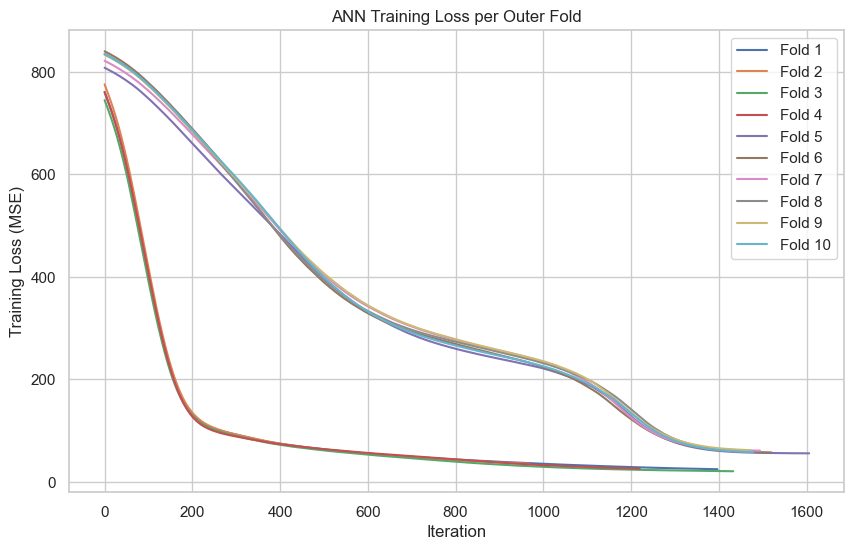

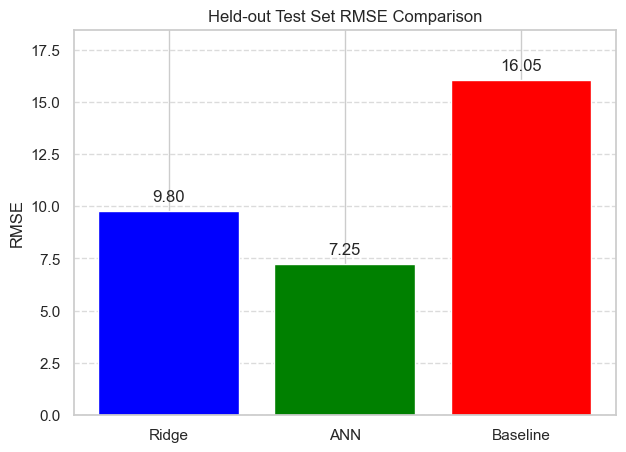

In [39]:
# Regression Part B # 

# λ values range
lambdas = np.logspace(-4, 4, 100)    
# Hidden units for ANN   
h_values = [1, 2, 5, 10, 20]              

# Cross-validation setup
K1 = K2 = 10
outer_cv = KFold(n_splits=K1, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=K2, shuffle=True, random_state=42)

# Model Pipelines 
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())                    
])

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        max_iter=2000,
        early_stopping=True,
        random_state=42
    ))
])

# Model Parameters
ridge_param_grid = {"ridge__alpha": lambdas}
ann_param_grid   = {"mlp__hidden_layer_sizes": [(h,) for h in h_values]}


results = []
ann_loss_curves = []

# Outer CV
for fold_number, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_te = y_train[train_idx], y_train[test_idx]

    # Baseline model (mean of y on training fold)
    baseline_pred = np.full_like(y_te, y_tr.mean(), dtype=float)
    baseline_mse  = mean_squared_error(y_te, baseline_pred)

    # Ridge Regression model
    ridge_gs = GridSearchCV(
        estimator=ridge_pipe,
        param_grid=ridge_param_grid,
        scoring="neg_mean_squared_error",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )
    ridge_gs.fit(X_tr, y_tr)
    best_lambda = ridge_gs.best_params_["ridge__alpha"]
    ridge_test_mse = mean_squared_error(y_te, ridge_gs.best_estimator_.predict(X_te))

    # ANN model
    ann_gs = GridSearchCV(
        estimator=mlp_pipe,
        param_grid=ann_param_grid,
        scoring="neg_mean_squared_error",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )
    ann_gs.fit(X_tr, y_tr)
    best_h = ann_gs.best_params_["mlp__hidden_layer_sizes"][0]
    ann_test_mse = mean_squared_error(y_te, ann_gs.best_estimator_.predict(X_te))
    best_ann = ann_gs.best_estimator_.named_steps["mlp"]
    ann_loss_curves.append(best_ann.loss_curve_)

    results.append({
        "Fold": fold_number,
        "h*": best_h,
        "ANN Test MSE": ann_test_mse,
        "λ*": best_lambda,
        "Ridge Test MSE": ridge_test_mse,
        "Baseline MSE": baseline_mse
    })

    print(f"Fold {fold_number}: λ*={best_lambda:.4f}, h*={best_h}, "
          f"Ridge MSE={ridge_test_mse:.3f}, ANN MSE={ann_test_mse:.3f}, "
          f"Baseline MSE={baseline_mse:.3f}")

# Show results in a table format
results_df = pd.DataFrame(results).sort_values("Fold")
display(results_df)

# Print the Average Test MSEs to compare the models 
print("\nAverage Test MSEs (Outer CV):")
print(results_df[["Ridge Test MSE", "ANN Test MSE", "Baseline MSE"]].mean())

# Baseline model assessment on held-out test set
baseline_rmse = np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean(), dtype=float)))

# Ridge Regression model assessment on held-out test
ridge_gs_final = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=inner_cv,
    n_jobs=-1,
    refit=True
).fit(X_train, y_train)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_gs_final.best_estimator_.predict(X_test)))

# ANN model assessment on held-out test
ann_gs_final = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=ann_param_grid,
    scoring="neg_mean_squared_error",
    cv=inner_cv,
    n_jobs=-1,
    refit=True
).fit(X_train, y_train)
ann_test_rmse   = np.sqrt(mean_squared_error(y_test, ann_gs_final.best_estimator_.predict(X_test)))

print("\nFinal Evaluation on Held-out Test Set:")
print(f"Ridge RMSE: {ridge_test_rmse:.3f}")
print(f"ANN RMSE:   {ann_test_rmse:.3f}")
print(f"Baseline:   {baseline_rmse:.3f}")

# ANN Loss Curves
plt.figure(figsize=(10,6))
for i, loss_curve in enumerate(ann_loss_curves):
    plt.plot(loss_curve, label=f'Fold {i+1}')
plt.xlabel('Iteration')
plt.ylabel('Training Loss (MSE)')
plt.title('ANN Training Loss per Outer Fold')
plt.legend()
plt.grid(True)
plt.show()

# Bar plot of held-out test RMSE
models = ['Ridge', 'ANN', 'Baseline']
rmse_values = [ridge_test_rmse, ann_test_rmse, baseline_rmse]

plt.figure(figsize=(7,5))
bars = plt.bar(models, rmse_values, color=['blue','green','red'])
plt.ylabel('RMSE')
plt.title('Held-out Test Set RMSE Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(rmse_values)*1.15)  # padding for labels

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.2f}',
             ha='center', va='bottom')
plt.show()


Pairwise Model Comparison (Paired t-test)
       Comparison   Mean ΔMSE  95% CI Lower  95% CI Upper      p-value  Significant (α=0.05)
     ANN vs Ridge  -16.324278    -40.441400      7.792844 1.600804e-01                 False
  ANN vs Baseline -187.785340   -226.465843   -149.104838 1.631973e-06                  True
Ridge vs Baseline -171.461063   -190.446396   -152.475729 7.525448e-09                  True


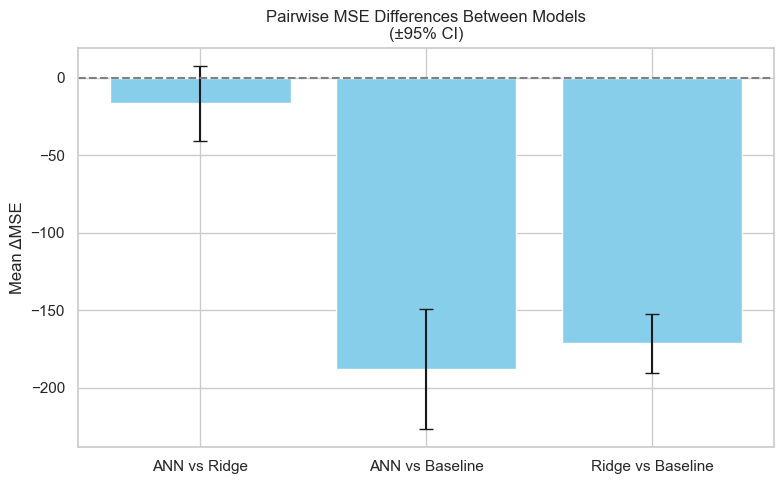

In [ ]:
from scipy.stats import ttest_rel, t
import seaborn as sns

# Compute Pairwise differences
ridge_mse = results_df['Ridge Test MSE'].values
ann_mse = results_df['ANN Test MSE'].values
baseline_mse = results_df['Baseline MSE'].values

z_ann_ridge = ann_mse - ridge_mse
z_ann_base = ann_mse - baseline_mse
z_ridge_base = ridge_mse - baseline_mse

# Paired t-tests
t_ann_ridge = ttest_rel(ann_mse, ridge_mse)
t_ann_base = ttest_rel(ann_mse, baseline_mse)
t_ridge_base = ttest_rel(ridge_mse, baseline_mse)

# Confidence Intervals
def confidence_interval(z, alpha=0.05):
    n = len(z)
    z_bar = np.mean(z)
    s = np.std(z, ddof=1)
    t_crit = t.ppf(1 - alpha/2, n - 1)
    margin = t_crit * s / np.sqrt(n)
    return z_bar - margin, z_bar + margin

ci_ann_ridge = confidence_interval(z_ann_ridge)
ci_ann_base = confidence_interval(z_ann_base)
ci_ridge_base = confidence_interval(z_ridge_base)

# Summary Table
summary = pd.DataFrame({
    "Comparison": ["ANN vs Ridge", "ANN vs Baseline", "Ridge vs Baseline"],
    "Mean ΔMSE": [np.mean(z_ann_ridge), np.mean(z_ann_base), np.mean(z_ridge_base)],
    "95% CI Lower": [ci_ann_ridge[0], ci_ann_base[0], ci_ridge_base[0]],
    "95% CI Upper": [ci_ann_ridge[1], ci_ann_base[1], ci_ridge_base[1]],
    "p-value": [t_ann_ridge.pvalue, t_ann_base.pvalue, t_ridge_base.pvalue]
})

summary["Significant (α=0.05)"] = summary["p-value"] < 0.05

print("\nPairwise Model Comparison (Paired t-test)\n")
print(summary.to_string(index=False))

# Plotting
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

# Data for plotting
comparisons = summary["Comparison"]
mean_delta = summary["Mean ΔMSE"]
ci_lower = summary["95% CI Lower"]
ci_upper = summary["95% CI Upper"]

# Compute error bars
error_lower = mean_delta - ci_lower
error_upper = ci_upper - mean_delta
error = [error_lower, error_upper]

# Bar plot with error bars
plt.bar(comparisons, mean_delta, yerr=error, capsize=5, color='skyblue')
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel("Mean ΔMSE")
plt.title("Pairwise MSE Differences Between Models\n(±95% CI)")
plt.tight_layout()
plt.show()
